# 🎬 Movie Recommendation System
### Item-Based Collaborative Filtering using MovieLens Dataset

In this notebook, I'm building a movie recommender from scratch using item-based collaborative filtering.
The idea is simple: given a movie I like, find other movies that were rated similarly by the same users.

## Step 1 — Import Libraries

I'm using `pandas` for data handling, `numpy` for math,
`scikit-learn` for cosine similarity, and `matplotlib`/`seaborn` for visualizations.

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load the MovieLens Full Dataset

Using the **MovieLens** dataset (~27M ratings, 58k movies, 280k users).

In [2]:
# Loading the two files needed: ratings and movie metadata
print('Loading ratings...')
ratings = pd.read_csv('ratings.csv')

print('Loading movies...')
movies = pd.read_csv('movies.csv')

print(f'\nRatings shape : {ratings.shape}')
print(f'Movies shape  : {movies.shape}')
ratings.head()

Loading ratings...
Loading movies...

Ratings shape : (25000095, 4)
Movies shape  : (62423, 3)


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Step 3 — Exploratory Data Analysis

Before building the model, I want to understand what the data looks like —
how many users and movies are there, what the rating distribution looks like, and how sparse the matrix will be.

In [4]:
print(f'Total ratings  : {len(ratings):,}')
print(f'Unique users   : {ratings["userId"].nunique():,}')
print(f'Unique movies  : {ratings["movieId"].nunique():,}')
print(f'Rating range   : {ratings["rating"].min()} to {ratings["rating"].max()}')

# Sparsity: what % of the user-movie matrix is empty (unrated)
total_possible = ratings['userId'].nunique() * ratings['movieId'].nunique()
sparsity = 1 - (len(ratings) / total_possible)
print(f'Matrix sparsity: {sparsity:.2%}')

Total ratings  : 25,000,095
Unique users   : 162,541
Unique movies  : 59,047
Rating range   : 0.5 to 5.0
Matrix sparsity: 99.74%


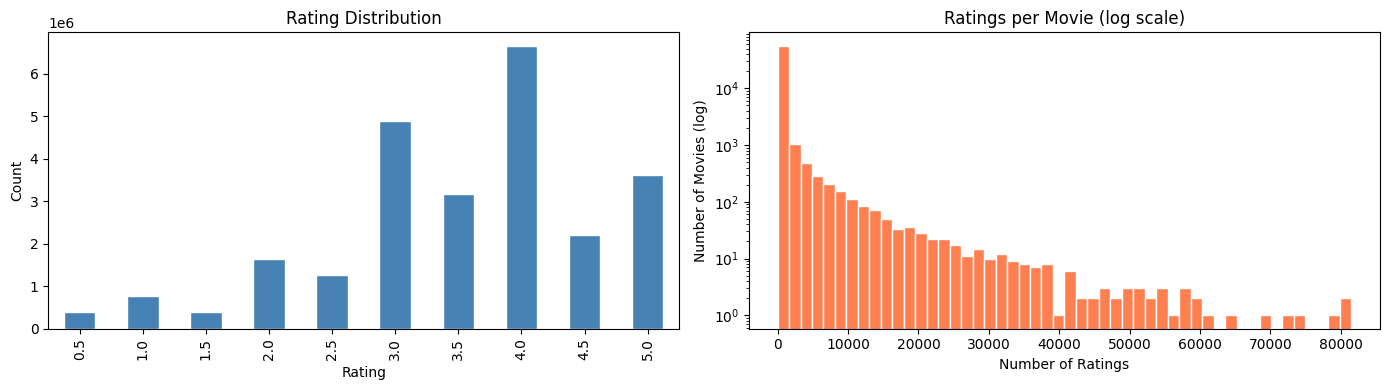

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating distribution — checking if users tend to rate high or low
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per movie — most movies have very few ratings (long tail effect)
ratings_per_movie = ratings.groupby('movieId')['rating'].count()
axes[1].hist(ratings_per_movie, bins=50, color='coral', edgecolor='white', log=True)
axes[1].set_title('Ratings per Movie (log scale)')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Movies (log)')

plt.tight_layout()
plt.show()

## Step 4 — Build the User-Movie Matrix

I need to reshape the data into a matrix where:
- **Rows** = users
- **Columns** = movie titles
- **Values** = ratings (NaN if I haven't rated that movie)

Because the full dataset is huge, I'm filtering to movies with at least **5000 ratings**.
This keeps only well-known movies, reduces noise, and keeps memory usage manageable.

In [6]:
# Merging ratings with movie titles so I have the title in every row
df = ratings.merge(movies[['movieId', 'title']], on='movieId')

# Filtering: only keep movies rated by at least 5000 users
# This removes obscure movies that would add noise to the similarity scores
min_ratings = 5000
movie_counts = df.groupby('title')['rating'].count()
movie_counts

title
"BLOW THE NIGHT!" Let's Spend the Night Together (1983)      1
"Great Performances" Cats (1998)                           179
#1 Cheerleader Camp (2010)                                   9
#Captured (2017)                                             2
#Female Pleasure (2018)                                      3
                                                          ... 
…And the Fifth Horseman Is Fear (1965)                       2
キサラギ (2007)                                                  2
チェブラーシカ (2010)                                               9
貞子3D (2012)                                                 12
줄탁동시 (2012)                                                  2
Name: rating, Length: 58958, dtype: int64

In [9]:
popular_movies = movie_counts[movie_counts >= min_ratings].index
df = df[df['title'].isin(popular_movies)]

print(f'Movies remaining after filtering (>= {min_ratings} ratings): {df["title"].nunique():,}')
print(f'Total ratings remaining: {len(df):,}')

Movies remaining after filtering (>= 5000 ratings): 1,223
Total ratings remaining: 16,358,490


In [10]:
# Building the user-movie pivot table
# This is the core data structure for collaborative filtering
print('Building user-movie matrix...')
user_movie_matrix = df.pivot_table(index='userId', columns='title', values='rating')

print(f'Matrix shape: {user_movie_matrix.shape}  (users x movies)')
user_movie_matrix.head(3)

Building user-movie matrix...
Matrix shape: (162520, 1223)  (users x movies)


title,(500) Days of Summer (2009),10 Things I Hate About You (1999),101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),12 Angry Men (1957),12 Years a Slave (2013),127 Hours (2010),13 Going on 30 (2004),"13th Warrior, The (1999)","2 Fast 2 Furious (Fast and the Furious 2, The) (2003)",...,You've Got Mail (1998),Young Frankenstein (1974),Young Guns (1988),Zodiac (2007),Zombieland (2009),Zoolander (2001),Zootopia (2016),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,4.0,3.5,NaN,NaN,3.5,NaN


## Step 5 — Compute Movie-to-Movie Cosine Similarity

Now I'll compute how similar every movie is to every other movie.
I fill missing ratings with 0 (treating unrated as neutral), then use **cosine similarity**.

> **Cosine similarity** measures the angle between two rating vectors.
> A score of **1.0** means identical rating patterns. **0.0** means no overlap at all.

The result is a movie x movie similarity matrix — the basis of my recommender.

In [11]:
# Filling NaN with 0 (unrated = neutral) and transposing so movies become rows
# Shape after transpose: (movies, users)
print('Computing cosine similarity matrix...')
matrix_filled = user_movie_matrix.fillna(0).T

# Computing pairwise cosine similarity between all movies
similarity_matrix = cosine_similarity(matrix_filled)

# Wrapping in a DataFrame so I can look up movies by title
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=matrix_filled.index,
    columns=matrix_filled.index
)

print(f'Similarity matrix shape: {similarity_df.shape}')
similarity_df.head(3)

Computing cosine similarity matrix...
Similarity matrix shape: (1223, 1223)


title,(500) Days of Summer (2009),10 Things I Hate About You (1999),101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),12 Angry Men (1957),12 Years a Slave (2013),127 Hours (2010),13 Going on 30 (2004),"13th Warrior, The (1999)","2 Fast 2 Furious (Fast and the Furious 2, The) (2003)",...,You've Got Mail (1998),Young Frankenstein (1974),Young Guns (1988),Zodiac (2007),Zombieland (2009),Zoolander (2001),Zootopia (2016),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer (2009),1.000000,0.262095,0.113679,0.124639,0.190838,0.259652,0.314361,0.229488,0.074086,0.150506,...,0.158903,0.089983,0.047261,0.285526,0.347848,0.223905,0.230014,0.095400,0.126900,0.068070
10 Things I Hate About You (1999),0.262095,1.000000,0.224428,0.241945,0.154656,0.108135,0.131487,0.334309,0.198611,0.179368,...,0.314807,0.153903,0.138128,0.153367,0.181040,0.260002,0.132946,0.139187,0.184608,0.168085
101 Dalmatians (1996),0.113679,0.224428,1.000000,0.338340,0.125421,0.068125,0.083618,0.187525,0.123162,0.158300,...,0.204969,0.152668,0.128687,0.097381,0.102678,0.157351,0.084105,0.079302,0.141167,0.133956


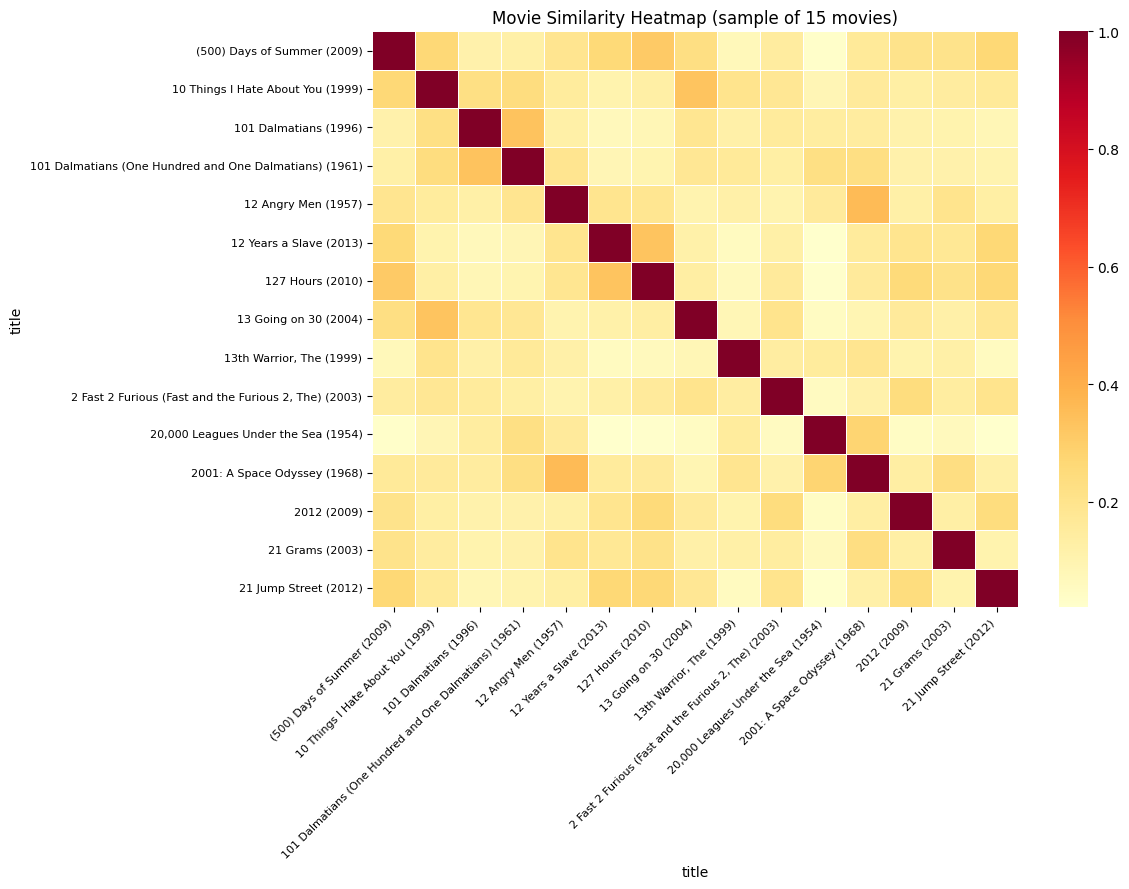

In [12]:
# Quick heatmap to visualize similarity scores for a small sample of movies
sample_movies = similarity_df.index[:15]
plt.figure(figsize=(12, 9))
sns.heatmap(
    similarity_df.loc[sample_movies, sample_movies],
    annot=False, cmap='YlOrRd', linewidths=0.5
)
plt.title('Movie Similarity Heatmap (sample of 15 movies)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Step 6 — Build the Recommender Functions

I'll write two functions:
- `get_recommendations()` — core logic, returns a ranked Series of similar movies
- `show_recommendations()` — pretty-prints the results as a formatted table

Both support a `similarity` argument so I can swap in different similarity matrices
(e.g. normalized or Pearson) without rewriting the functions.
I'm using `**kwargs` in `show_recommendations()` so it forwards any extra arguments
directly to `get_recommendations()` — this fixes the `TypeError` from before.

In [13]:
def get_recommendations(movie_title, n=10, similarity=similarity_df):
    """
    Returns the top-N movies most similar to the one I provide.

    Parameters:
        movie_title (str) : Full or partial movie title (case-insensitive).
        n           (int) : How many recommendations to return (default: 10).
        similarity  (df)  : Similarity DataFrame to use for scoring.

    Returns:
        pd.Series: Top-N similar movies ranked by similarity score.
    """
    # Fuzzy search: find all titles that contain my input string
    matches = [t for t in similarity.index if movie_title.lower() in t.lower()]

    if not matches:
        print(f'No movie found matching "{movie_title}".')
        print('Tip: try a partial title, e.g. "Matrix" instead of "The Matrix (1999)"')
        return None

    # If there are multiple matches, I'll use the first one and show the others
    matched_title = matches[0]
    if len(matches) > 1:
        print(f'Multiple matches found. Using: "{matched_title}"')
        extras = ', '.join(matches[1:4])
        suffix = '...' if len(matches) > 4 else ''
        print(f'Other matches: {extras}{suffix}\n')

    print(f'Top {n} recommendations for: "{matched_title}"\n')

    # Get similarity scores for this movie, drop the movie itself, sort highest first
    scores = similarity[matched_title].drop(index=matched_title).sort_values(ascending=False)

    return scores.head(n)


def show_recommendations(movie_title, n=10, **kwargs):
    """
    Pretty-prints recommendations as a ranked table.
    Uses **kwargs to forward arguments like similarity= to get_recommendations().
    """
    results = get_recommendations(movie_title, n, **kwargs)  # kwargs fix: similarity= now works
    if results is not None:
        result_df = results.reset_index()
        result_df.columns = ['Movie Title', 'Similarity Score']
        result_df.index += 1  # rank starts at 1, not 0
        result_df['Similarity Score'] = result_df['Similarity Score'].round(4)
        display(result_df)


print('Recommender functions ready!')

Recommender functions ready!


## Step 7 — Test the Recommender

In [14]:
show_recommendations('Toy Story')

Multiple matches found. Using: "Toy Story (1995)"
Other matches: Toy Story 2 (1999), Toy Story 3 (2010)

Top 10 recommendations for: "Toy Story (1995)"



,Movie Title,Similarity Score
1,Star Wars: Episode IV - A New Hope (1977),0.5673
2,Toy Story 2 (1999),0.5636
3,Back to the Future (1985),0.5481
4,Forrest Gump (1994),0.5438
5,Jurassic Park (1993),0.5397
6,Star Wars: Episode VI - Return of the Jedi (1983),0.5388
7,Independence Day (a.k.a. ID4) (1996),0.5377
8,"Lion King, The (1994)",0.5307
9,Aladdin (1992),0.5287
10,Star Wars: Episode V - The Empire Strikes Back...,0.5133


In [15]:
show_recommendations('Pulp Fiction')

Top 10 recommendations for: "Pulp Fiction (1994)"



,Movie Title,Similarity Score
1,"Silence of the Lambs, The (1991)",0.7034
2,"Shawshank Redemption, The (1994)",0.6753
3,Seven (a.k.a. Se7en) (1995),0.6525
4,"Usual Suspects, The (1995)",0.6509
5,Forrest Gump (1994),0.6440
6,Fight Club (1999),0.6135
7,Reservoir Dogs (1992),0.6081
8,Fargo (1996),0.5848
9,"Matrix, The (1999)",0.5848
10,Terminator 2: Judgment Day (1991),0.5818


In [16]:
show_recommendations('The Matrix')

No movie found matching "The Matrix".
Tip: try a partial title, e.g. "Matrix" instead of "The Matrix (1999)"


## Step 8 — Improvements

A few improvements I can layer on top of the base model:

In [17]:
# ── Stretch Goal 1: Normalize ratings by user mean ───────────────────────────
# Some users always give 5 stars (generous) and others always give 2 stars (harsh).
# By subtracting each user's mean rating, I center everyone around 0,
# which makes the similarity scores fairer and less biased by rating style.

user_mean = user_movie_matrix.mean(axis=1)
normalized_matrix = user_movie_matrix.sub(user_mean, axis=0).fillna(0)

norm_similarity = cosine_similarity(normalized_matrix.T)
norm_similarity_df = pd.DataFrame(
    norm_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

In [18]:
print('Recommendations using normalized ratings:\n')
show_recommendations('Matrix', similarity=norm_similarity_df)

Recommendations using normalized ratings:

Multiple matches found. Using: "Matrix Reloaded, The (2003)"
Other matches: Matrix Revolutions, The (2003), Matrix, The (1999)

Top 10 recommendations for: "Matrix Reloaded, The (2003)"



,Movie Title,Similarity Score
1,"Matrix Revolutions, The (2003)",0.5295
2,Star Wars: Episode II - Attack of the Clones (...,0.2452
3,Star Wars: Episode I - The Phantom Menace (1999),0.1979
4,Star Wars: Episode III - Revenge of the Sith (...,0.1806
5,Terminator 3: Rise of the Machines (2003),0.1401
6,"I, Robot (2004)",0.1375
7,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...,0.1331
8,Mission: Impossible II (2000),0.1319
9,X-Men: The Last Stand (2006),0.1232
10,Armageddon (1998),0.1232


In [19]:
# ── Stretch Goal 2: Pearson Correlation instead of Cosine Similarity ──────────
# Pearson correlation is often a better fit for ratings data because it naturally
# accounts for differences in each user's rating scale — similar to normalization above.

print('Computing Pearson correlation matrix... (may take a moment)')
pearson_similarity_df = user_movie_matrix.corr(method='pearson')
print('Pearson correlation matrix computed.')

Computing Pearson correlation matrix... (may take a moment)
Pearson correlation matrix computed.


In [20]:
print('Recommendations using Pearson Correlation:\n')
show_recommendations('Toy Story', similarity=pearson_similarity_df)

Recommendations using Pearson Correlation:

Multiple matches found. Using: "Toy Story (1995)"
Other matches: Toy Story 2 (1999), Toy Story 3 (2010)

Top 10 recommendations for: "Toy Story (1995)"



,Movie Title,Similarity Score
1,Toy Story 2 (1999),0.7485
2,Toy Story 3 (2010),0.6877
3,"Monsters, Inc. (2001)",0.5622
4,Finding Nemo (2003),0.5342
5,"Bug's Life, A (1998)",0.5337
6,"Incredibles, The (2004)",0.4859
7,Up (2009),0.4619
8,Aladdin (1992),0.4566
9,"Lion King, The (1994)",0.4436
10,Ratatouille (2007),0.4393


In [21]:
# ── Stretch Goal 3: Search for movies by keyword ──────────────────────────────
# Useful when I'm not sure of the exact title stored in the dataset

def search_movies(keyword):
    """Prints all movies in my dataset whose title contains the given keyword."""
    matches = [t for t in similarity_df.index if keyword.lower() in t.lower()]
    print(f'{len(matches)} movie(s) found for "{keyword}":')
    for m in matches:
        print(f'  - {m}')

In [22]:
search_movies('Star Wars')

8 movie(s) found for "Star Wars":
  - Rogue One: A Star Wars Story (2016)
  - Star Wars: Episode I - The Phantom Menace (1999)
  - Star Wars: Episode II - Attack of the Clones (2002)
  - Star Wars: Episode III - Revenge of the Sith (2005)
  - Star Wars: Episode IV - A New Hope (1977)
  - Star Wars: Episode V - The Empire Strikes Back (1980)
  - Star Wars: Episode VI - Return of the Jedi (1983)
  - Star Wars: Episode VII - The Force Awakens (2015)


#### Saving to parquet files for faster loading

In [23]:
# Precompute and save — run this once
similarity_df.to_parquet('similarity_cosine.parquet')
norm_similarity_df.to_parquet('similarity_normalized.parquet')
pearson_similarity_df.to_parquet('similarity_pearson.parquet')

## Step 9 — Interactive Input 🎯

This is the final cell. I can type any movie title here and get my recommendations instantly.
Partial titles work too — so `"Avengers"` will match `"The Avengers (2012)"` and similar entries.

I can also choose how many recommendations I want, and which similarity method to use.

In [23]:
# ── Interactive Recommender ───────────────────────────────────────────────────

# Mapping my choice of method to the corresponding similarity matrix
similarity_options = {
    '1': ('Cosine Similarity',           similarity_df),
    '2': ('Normalized Cosine Similarity', norm_similarity_df),
    '3': ('Pearson Correlation',          pearson_similarity_df),
}

print('=== Movie Recommender ===')
movie_input = input('Enter a movie title (or partial title): ').strip()
num_recs    = input('How many recommendations? (press Enter for 10): ').strip()
print('\nSimilarity method:')
print('  1 - Cosine Similarity (default)')
print('  2 - Normalized Cosine Similarity')
print('  3 - Pearson Correlation')
method_choice = input('Choose method (1/2/3, press Enter for 1): ').strip() or '1'

# Defaults if I leave inputs blank
num_recs = int(num_recs) if num_recs.isdigit() else 10
method_choice = method_choice if method_choice in similarity_options else '1'

method_name, chosen_similarity = similarity_options[method_choice]

print(f'\n{"─" * 50}')
print(f'Method: {method_name}')
print(f'{"─" * 50}\n')

show_recommendations(movie_input, n=num_recs, similarity=chosen_similarity)

=== Movie Recommender ===


Enter a movie title (or partial title):  Inception
How many recommendations? (press Enter for 10):  15



Similarity method:
  1 - Cosine Similarity (default)
  2 - Normalized Cosine Similarity
  3 - Pearson Correlation


Choose method (1/2/3, press Enter for 1):  3



──────────────────────────────────────────────────
Method: Pearson Correlation
──────────────────────────────────────────────────

Top 15 recommendations for: "Inception (2010)"



,Movie Title,Similarity Score
1,Interstellar (2014),0.4620
2,Shutter Island (2010),0.4356
3,"Dark Knight Rises, The (2012)",0.4273
4,"Dark Knight, The (2008)",0.4135
5,"Prestige, The (2006)",0.3940
6,Batman Begins (2005),0.3724
7,Minority Report (2002),0.3602
8,Memento (2000),0.3587
9,Source Code (2011),0.3501
10,"Matrix Reloaded, The (2003)",0.3440


---
## Summary

| Step | What I did |
|------|------------|
| 1 | Imported libraries |
| 2 | Loaded the MovieLens Full dataset from disk |
| 3 | Explored rating distributions and matrix sparsity |
| 4 | Built a user-movie matrix, filtered to movies with 200+ ratings |
| 5 | Computed cosine similarity between all movie pairs |
| 6 | Built `get_recommendations()` and `show_recommendations()` with `**kwargs` fix |
| 7 | Tested with Toy Story, Pulp Fiction, The Matrix |
| 8 | Added rating normalization, Pearson correlation, and movie keyword search |
| 9 | Added an interactive input cell with method selection |

**What I could explore next:**
- Build a browser UI with `Streamlit` so I can share it with others
- Try SVD / matrix factorization using the `Surprise` library
- Combine with content-based filtering (genres, cast) for a hybrid system